In [ ]:
import numpy as np
import pandas as pd

## 1차

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/까르띠에_감성분석 BERT용 라벨링 데이터_V3.xlsx')
df.head(2)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/까르띠에_감성분석 BERT용 라벨링 데이터_V3.xlsx'

In [ ]:
df['label'].isnull().sum()

np.int64(0)

In [ ]:
df['label'].value_counts()

,count
label,
2,215
3,147
1,145
4,55
0,38


In [ ]:
mask = (df['label'] == 4)
df = df[~mask]
print(f"까르띠에 데이터 개수 : {len(df)} 개")

까르띠에 데이터 개수 : 545 개


In [ ]:
def map_binary_label(x):
    if x in [0, 1]:      # 부정 / 중립불안
        return 1         # 리스크
    elif x in [2, 3]:     # 중립 / 긍정
        return 0         # 비리스크

df['two_label'] = df['label'].apply(map_binary_label)
df.head(2)

In [ ]:
df['two_label'].value_counts()

,count
two_label,
0,362
1,183


In [ ]:
import random
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm

# 모델 설정
model_name = "beomi/KcBERT-base"
num_labels = 2
batch_size = 16
epochs = 3
max_length = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
texts = df["text"].tolist()
labels = df["two_label"].tolist()

In [ ]:
import torch

# 클래스 샘플 수
n0 = len(df[df['two_label'] == 0])
n1 = len(df[df['two_label'] == 1])

N = n0 + n1
k = 2  # 클래스 개수

# 역비율 가중치
class_weights = torch.tensor([
    N / (k * n0),  # 리스크
    N / (k * n1),  # 비리스크
], dtype=torch.float)

print(class_weights)

tensor([0.7528, 1.4891])


In [ ]:
df['two_label'].unique()

array([1, 0])

In [ ]:
# 3. Train / Validation 분리
from sklearn.model_selection import train_test_split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(class_weights)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Loss (가중치 적용)
criterion = nn.CrossEntropyLoss(weight=class_weights)

tensor([0.7528, 1.4891])


/tmp/ipykernel_5703/3116789382.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)


In [ ]:
df_train = pd.DataFrame({
    "text": train_texts,
    "label": train_labels
})
len(df_train)

436

In [ ]:
df_test = pd.DataFrame({
    "text": val_texts,
    "label": val_labels
})
len(df_test)

109

In [ ]:
# 4. Dataset 클래스
tokenizer = AutoTokenizer.from_pretrained(model_name)

class CustomDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = CustomDataset(texts, labels)
val_dataset = CustomDataset(val_texts, val_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# 5. 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
# 6. 학습 + 검증
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
            )

        logits = outputs.logits
        # weighted loss 적용
        loss = criterion(logits, labels)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    print(f"\nEpoch {epoch+1} Train Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 28/28 [00:09<00:00,  2.86it/s]



Epoch 1 Train Loss: 0.6621


100%|██████████| 28/28 [00:08<00:00,  3.20it/s]



Epoch 2 Train Loss: 0.4832


100%|██████████| 28/28 [00:08<00:00,  3.16it/s]


Epoch 3 Train Loss: 0.2811


In [ ]:
# Validation 평가
from sklearn.metrics import accuracy_score, f1_score

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())  # 1 = 리스크

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Validation Macro F1: {f1:.4f}")



Validation Accuracy: 0.7523
Validation Macro F1: 0.7137



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82        72
           1       0.66      0.57      0.61        37

    accuracy                           0.75       109
   macro avg       0.72      0.71      0.71       109
weighted avg       0.75      0.75      0.75       109



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

thresholds = np.arange(0.3, 0.71, 0.05)

results = []

for t in thresholds:

    preds = (np.array(all_probs) >= t).astype(int)

    precision0 = precision_score(all_labels, preds, pos_label=0)
    recall0 = recall_score(all_labels, preds, pos_label=0)
    f10 = f1_score(all_labels, preds, pos_label=0)

    precision1 = precision_score(all_labels, preds, pos_label=1)
    recall1 = recall_score(all_labels, preds, pos_label=1)
    f11 = f1_score(all_labels, preds, pos_label=1)

    results.append([t, precision0, recall0, f10, precision1, recall1, f11])

df_threshold = pd.DataFrame(
    results,
    columns=[
        "threshold",
        "precision_0",
        "recall_0",
        "f1_0",
        "precision_1",
        "recall_1",
        "f1_1"
    ]
)

print(df_threshold)

   threshold  precision_0  recall_0      f1_0  precision_1  recall_1      f1_1
0       0.30     0.797297  0.819444  0.808219     0.628571  0.594595  0.611111
1       0.35     0.800000  0.833333  0.816327     0.647059  0.594595  0.619718
2       0.40     0.792208  0.847222  0.818792     0.656250  0.567568  0.608696
3       0.45     0.792208  0.847222  0.818792     0.656250  0.567568  0.608696
4       0.50     0.792208  0.847222  0.818792     0.656250  0.567568  0.608696
5       0.55     0.787500  0.875000  0.828947     0.689655  0.540541  0.606061
6       0.60     0.768293  0.875000  0.818182     0.666667  0.486486  0.562500
7       0.65     0.764706  0.902778  0.828025     0.708333  0.459459  0.557377
8       0.70     0.750000  0.916667  0.825000     0.714286  0.405405  0.517241


In [ ]:
from sklearn.metrics import confusion_matrix

threshold = 0.30

y_true = np.array(all_labels)
y_score = np.array(all_probs)

y_pred = (y_score >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

TP: 22, FP: 13, FN: 15, TN: 59


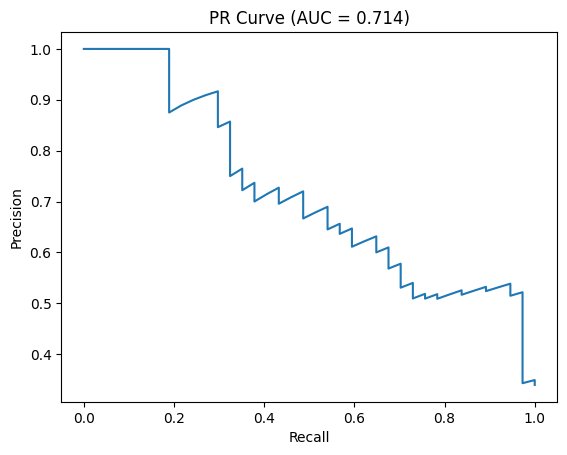

In [ ]:
# PR Curve
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

y_true = np.array(all_labels)   # 리스크=1
y_score = np.array(all_probs)

precision, recall, _ = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AUC = {pr_auc:.3f})")
plt.show()

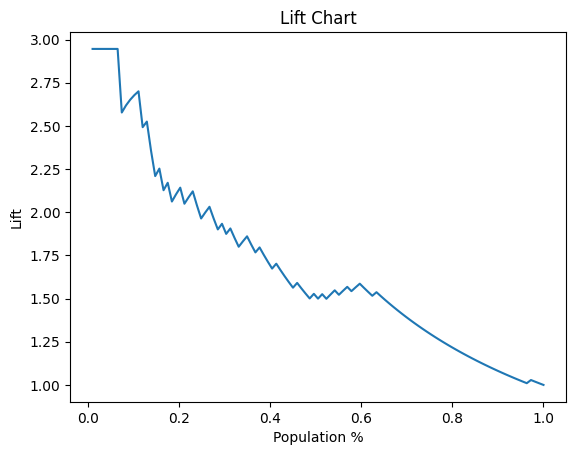

In [ ]:
# Lift Chart (정상 버전)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

y_true = np.array(all_labels)   # 리스크=1
y_score = np.array(all_probs)

df_lift = pd.DataFrame({
    "prob": y_score,
    "label": y_true
})

df_lift = df_lift.sort_values("prob", ascending=False).reset_index(drop=True)

# 누적
df_lift["cum_risk"] = df_lift["label"].cumsum()
df_lift["cum_total"] = np.arange(1, len(df_lift)+1)

# 전체 리스크 비율
baseline = df_lift["label"].sum() / len(df_lift)

# 누적 리스크 비율
df_lift["cum_risk_rate"] = df_lift["cum_risk"] / df_lift["cum_total"]

# Lift
df_lift["lift"] = df_lift["cum_risk_rate"] / baseline

# x축
df_lift["population_pct"] = df_lift["cum_total"] / len(df_lift)

# 그래프
plt.figure()
plt.plot(df_lift["population_pct"], df_lift["lift"])
plt.xlabel("Population %")
plt.ylabel("Lift")
plt.title("Lift Chart")
plt.show()


In [ ]:
df_bin = pd.DataFrame({
    "prob": all_probs,
    "label": all_labels
})

df_bin["risk"] = df_bin["label"]

# 구간별로 쪼개기
df_bin["bin"] = pd.qcut(df_bin["prob"], 10, duplicates="drop")

# 각 구간 리스크 비율
lift_check = df_bin.groupby("bin")["risk"].mean()

print(lift_check)

bin
(0.00429, 0.00886]    0.090909
(0.00886, 0.014]      0.000000
(0.014, 0.029]        0.000000
(0.029, 0.0554]       0.090909
(0.0554, 0.1]         0.636364
(0.1, 0.171]          0.300000
(0.171, 0.355]        0.363636
(0.355, 0.679]        0.454545
(0.679, 0.891]        0.545455
(0.891, 0.976]        0.909091
Name: risk, dtype: float64


/tmp/ipykernel_5703/373596651.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lift_check = df_bin.groupby("bin")["risk"].mean()


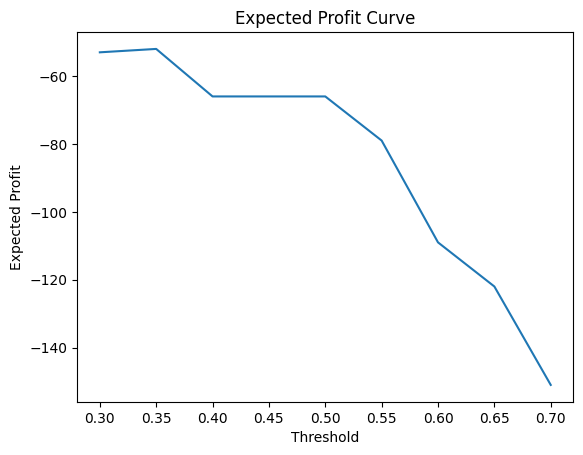

In [ ]:
# Expected Profit
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.3, 0.71, 0.05)
profits = []

benefit_tp = 5
cost_fp = 1
cost_fn = 10

for t in thresholds:
    preds = (all_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

    profit = tp * benefit_tp - fp * cost_fp - fn * cost_fn
    profits.append(profit)

plt.figure()
plt.plot(thresholds, profits)
plt.xlabel("Threshold")
plt.ylabel("Expected Profit")
plt.title("Expected Profit Curve")
plt.show()

전체에 적용

In [ ]:
df_all = pd.read_csv('/content/drive/MyDrive/final_cartier_only (1).csv')
print(f"전체 데이터 수 : {len(df_all)}개")

전체 데이터 수 : 5296개


In [ ]:
# 전체에서 라벨링된 id 제거
unlabeled_df = df_all[~df_all['naver_article_id'].isin(df['naver_article_id'])]
print(f"전체 데이터 수 : {len(unlabeled_df)}개")

전체 데이터 수 : 4751개


In [ ]:
from torch.utils.data import Dataset, DataLoader

class UnlabeledDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        encoding = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "text": text
        }

In [ ]:
unlabeled_texts = unlabeled_df['text'].tolist()

unlabeled_dataset = UnlabeledDataset(unlabeled_texts)

unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=16,
    shuffle=False
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

results = []

with torch.no_grad():
    for batch in tqdm(unlabeled_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        texts = batch["text"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

        top2 = torch.topk(probs, 2, dim=1)
        margin = top2.values[:, 0] - top2.values[:, 1]

        for i in range(len(texts)):
            results.append({
                "text": texts[i],
                "pred_label": torch.argmax(probs[i]).item(),
                "margin": margin[i].item(),
                "pred_prob": probs[i, 1].item(),
            })

df_pred = pd.DataFrame(results)
# df_pred.head()

100%|██████████| 297/297 [00:34<00:00,  8.65it/s]


In [ ]:
df_pred['pred_label'].value_counts()

,count
pred_label,
0,3579
1,1172


In [ ]:
high_risk = df_pred[df_pred["pred_prob"] >= 0.8].sample(50, random_state=42)
high_safe = df_pred[df_pred["pred_prob"] <= 0.1].sample(50, random_state=42)
final_sample = pd.concat([high_risk, high_safe]).drop_duplicates().reset_index(drop=True)
final_sample.to_excel("확신100.xlsx")

## 2차

추가학습1

In [ ]:
fin_ambiguous_100 = pd.read_excel('/content/drive/MyDrive/확신100완료.xlsx')
fin_ambiguous_100 = fin_ambiguous_100.drop(columns="Unnamed: 0")
fin_ambiguous_100.head(2)

In [ ]:
fin_ambiguous_100['label'].value_counts()

,count
label,
0.0,50
1.0,44
2.0,2


In [ ]:
train_100 = fin_ambiguous_100[fin_ambiguous_100['label'].isin([0,1])]
len(train_100)

94

In [ ]:
df_train2 = pd.concat([df_train, train_100], ignore_index = True)
df_train2 = df_train2.drop_duplicates(subset="text")
len(df_train2)

530

In [ ]:
df_train['label'].value_counts()

,count
label,
0,290
1,146


In [ ]:
df_train2['label'].value_counts()

,count
label,
0.0,340
1.0,190


In [ ]:
df_train2['label'].isnull().sum()

np.int64(0)

In [ ]:
print(len(df_train2))
print(len(df_train2["text"]))
print(len(df_train2["label"]))

530
530
530


In [ ]:
texts = df_train2["text"].tolist()
labels = df_train2["label"].tolist()

val_texts = df_test["text"].tolist()
val_labels = df_test["label"].tolist()

print(f"학습 데이터 : {len(df_train2)}개")
print(f"테스트 데이터 : {len(df_test)}개")

학습 데이터 : 530개
테스트 데이터 : 109개


In [ ]:
# 클래스 샘플 수
n0 = len(df_train2[df_train2['label'] == 0])
n1 = len(df_train2[df_train2['label'] == 1])

print(f"비리스크 데이터 : {n0}개")
print(f"리스크 데이터 : {n1}개")

N = n0 + n1
k = 2  # 클래스 개수

# 역비율 가중치
class_weights = torch.tensor([
    N / (k * n0),  # 비리스크
    N / (k * n1),  # 리스크
], dtype=torch.float)

print(class_weights)

In [ ]:
# Dataset 클래스
tokenizer = AutoTokenizer.from_pretrained(model_name)

class CustomDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = CustomDataset(texts, labels)
val_dataset = CustomDataset(val_texts, val_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
import random
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# 학습 + 검증

# criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
            )

        logits = outputs.logits
        # weighted loss 적용
        loss = criterion(logits, labels)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    print(f"\nEpoch {epoch+1} Train Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 28/28 [00:09<00:00,  2.94it/s]



Epoch 1 Train Loss: 0.2048


100%|██████████| 28/28 [00:09<00:00,  2.85it/s]



Epoch 2 Train Loss: 0.0909


100%|██████████| 28/28 [00:10<00:00,  2.76it/s]


Epoch 3 Train Loss: 0.0318


In [ ]:
# Validation 평가
from sklearn.metrics import accuracy_score, f1_score

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())  # 1 = 리스크 확률

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Validation Macro F1: {f1:.4f}")



Validation Accuracy: 0.7523
Validation Macro F1: 0.7091



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82        72
           1       0.67      0.54      0.60        37

    accuracy                           0.75       109
   macro avg       0.73      0.70      0.71       109
weighted avg       0.74      0.75      0.75       109



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

thresholds = np.arange(0.3, 0.71, 0.05)

results = []

for t in thresholds:

    preds = (np.array(all_probs) >= t).astype(int)

    precision0 = precision_score(all_labels, preds, pos_label=0)
    recall0 = recall_score(all_labels, preds, pos_label=0)
    f10 = f1_score(all_labels, preds, pos_label=0)

    precision1 = precision_score(all_labels, preds, pos_label=1)
    recall1 = recall_score(all_labels, preds, pos_label=1)
    f11 = f1_score(all_labels, preds, pos_label=1)

    results.append([t, precision0, recall0, f10, precision1, recall1, f11])

df_threshold = pd.DataFrame(
    results,
    columns=[
        "threshold",
        "precision_0",
        "recall_0",
        "f1_0",
        "precision_1",
        "recall_1",
        "f1_1"
    ]
)

print(df_threshold)

   threshold  precision_0  recall_0      f1_0  precision_1  recall_1      f1_1
0       0.30     0.792208  0.847222  0.818792     0.656250  0.567568  0.608696
1       0.35     0.794872  0.861111  0.826667     0.677419  0.567568  0.617647
2       0.40     0.784810  0.861111  0.821192     0.666667  0.540541  0.597015
3       0.45     0.784810  0.861111  0.821192     0.666667  0.540541  0.597015
4       0.50     0.784810  0.861111  0.821192     0.666667  0.540541  0.597015
5       0.55     0.787500  0.875000  0.828947     0.689655  0.540541  0.606061
6       0.60     0.790123  0.888889  0.836601     0.714286  0.540541  0.615385
7       0.65     0.792683  0.902778  0.844156     0.740741  0.540541  0.625000
8       0.70     0.785714  0.916667  0.846154     0.760000  0.513514  0.612903


In [ ]:
from sklearn.metrics import confusion_matrix

threshold = 0.35

y_true = np.array(all_labels)
y_score = np.array(all_probs)

y_pred = (y_score >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

TP: 21, FP: 10, FN: 16, TN: 62


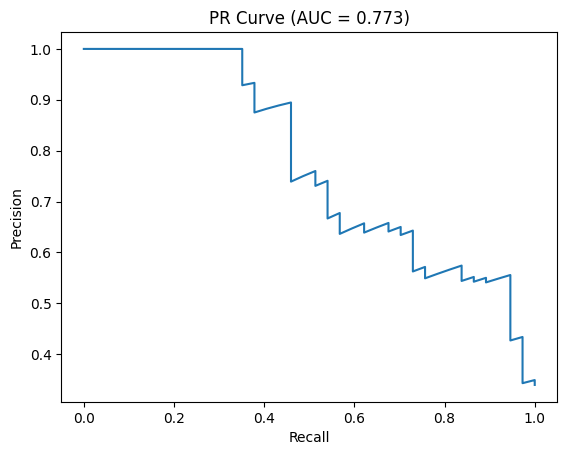

In [ ]:
# PR Curve
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

y_true = np.array(all_labels)   # 리스크=1
y_score = np.array(all_probs)

precision, recall, _ = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AUC = {pr_auc:.3f})")
plt.show()

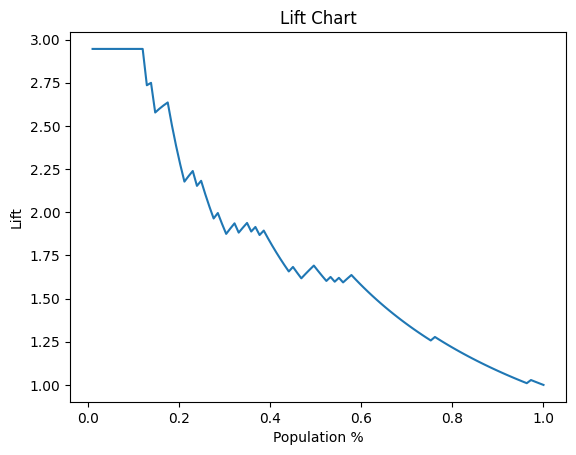

In [ ]:
# Lift Chart
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

y_true = np.array(all_labels)   # 리스크=1
y_score = np.array(all_probs)

df_lift = pd.DataFrame({
    "prob": y_score,
    "label": y_true
})

df_lift = df_lift.sort_values("prob", ascending=False).reset_index(drop=True)

# 누적
df_lift["cum_risk"] = df_lift["label"].cumsum()
df_lift["cum_total"] = np.arange(1, len(df_lift)+1)

# 전체 리스크 비율
baseline = df_lift["label"].sum() / len(df_lift)

# 누적 리스크 비율
df_lift["cum_risk_rate"] = df_lift["cum_risk"] / df_lift["cum_total"]

# 진짜 Lift
df_lift["lift"] = df_lift["cum_risk_rate"] / baseline

# x축
df_lift["population_pct"] = df_lift["cum_total"] / len(df_lift)

# 그래프
plt.figure()
plt.plot(df_lift["population_pct"], df_lift["lift"])
plt.xlabel("Population %")
plt.ylabel("Lift")
plt.title("Lift Chart")
plt.show()

In [ ]:
df_bin = pd.DataFrame({
    "prob": all_probs,
    "label": all_labels
})

df_bin["risk"] = df_bin["label"]

# 구간별로 쪼개기
df_bin["bin"] = pd.qcut(df_bin["prob"], 10, duplicates="drop")

# 각 구간 리스크 비율
lift_check = df_bin.groupby("bin")["risk"].mean()

print(lift_check)

bin
(-0.00020899999999999998, 0.00113]    0.090909
(0.00113, 0.00141]                    0.000000
(0.00141, 0.00232]                    0.090909
(0.00232, 0.00407]                    0.000000
(0.00407, 0.0156]                     0.363636
(0.0156, 0.0576]                      0.400000
(0.0576, 0.253]                       0.545455
(0.253, 0.843]                        0.363636
(0.843, 0.985]                        0.545455
(0.985, 0.997]                        1.000000
Name: risk, dtype: float64


/tmp/ipykernel_5703/373596651.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lift_check = df_bin.groupby("bin")["risk"].mean()


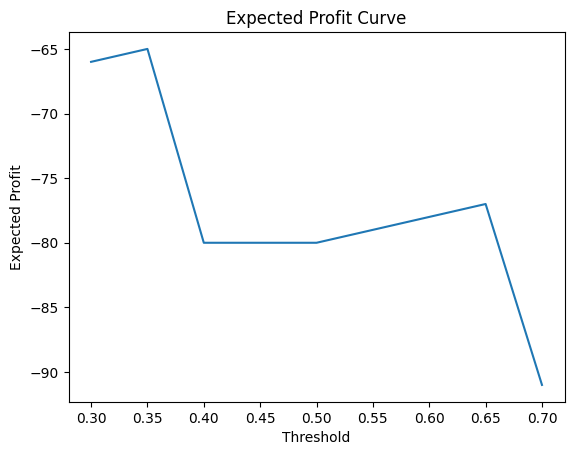

In [ ]:
# Expected Profit
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.3, 0.71, 0.05)
profits = []

benefit_tp = 5
cost_fp = 1
cost_fn = 10

for t in thresholds:
    preds = (all_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

    profit = tp * benefit_tp - fp * cost_fp - fn * cost_fn
    profits.append(profit)

plt.figure()
plt.plot(thresholds, profits)
plt.xlabel("Threshold")
plt.ylabel("Expected Profit")
plt.title("Expected Profit Curve")
plt.show()

In [ ]:
df_train2.columns

Index(['text', 'label', 'pred_label', 'margin', 'pred_prob'], dtype='object')

In [ ]:
# 전체에서 라벨링된 id 제거
unlabeled_df2 = unlabeled_df[~unlabeled_df['text'].isin(df_train2['text'])]
print(f"전체 데이터 수 : {len(unlabeled_df2)}개")

전체 데이터 수 : 4657개


In [ ]:
from torch.utils.data import Dataset, DataLoader

class UnlabeledDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        encoding = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "text": text
        }

In [ ]:
unlabeled_texts = unlabeled_df2['text'].tolist()

unlabeled_dataset = UnlabeledDataset(unlabeled_texts)

unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=16,
    shuffle=False
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

results = []

with torch.no_grad():
    for batch in tqdm(unlabeled_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        texts = batch["text"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

        top2 = torch.topk(probs, 2, dim=1)
        margin = top2.values[:, 0] - top2.values[:, 1]

        for i in range(len(texts)):
            results.append({
                "text": texts[i],
                "pred_label": torch.argmax(probs[i]).item(),
                "margin": margin[i].item(),
                "pred_prob": probs[i, 1].item(),
            })

df_pred = pd.DataFrame(results)
# df_pred.head()

100%|██████████| 292/292 [00:40<00:00,  7.29it/s]


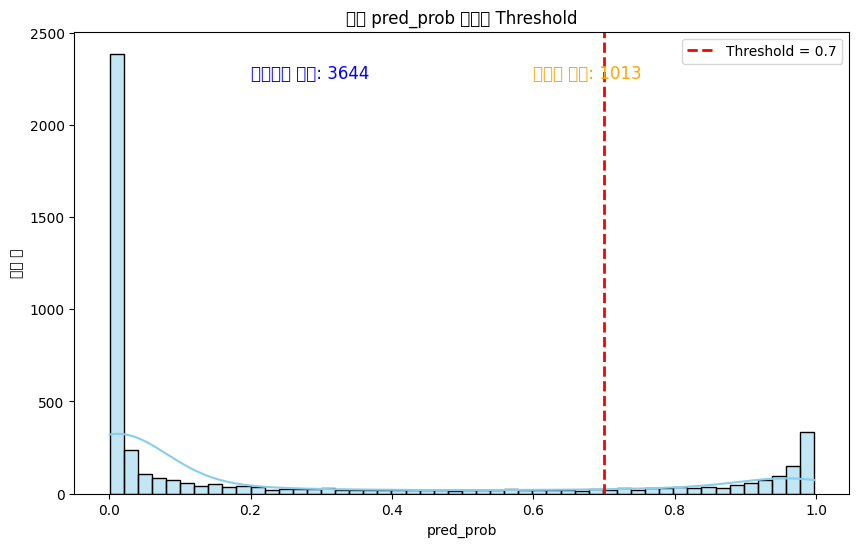

In [ ]:
import seaborn as sns

threshold = 0.7

plt.figure(figsize=(10,6))
sns.histplot(df_pred['pred_prob'], bins=50, kde=True, color='skyblue')

plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold}')

# 영역별 개수 표시
below_threshold = (df_pred['pred_prob'] < threshold).sum()
above_threshold = (df_pred['pred_prob'] >= threshold).sum()
plt.text(0.2, plt.ylim()[1]*0.9, f'비리스크 샘플: {below_threshold}', fontsize=12, color='blue')
plt.text(0.6, plt.ylim()[1]*0.9, f'리스크 샘플: {above_threshold}', fontsize=12, color='orange')

plt.title('모델 pred_prob 분포와 Threshold')
plt.xlabel('pred_prob')
plt.ylabel('샘플 수')
plt.legend()
plt.show()

In [ ]:
# pred_prob 0.45 ~ 0.55 기준
ambiguous_candidates = df_pred[(df_pred['pred_prob'] >= 0.45) & (df_pred['pred_prob'] < 0.55)]
ambiguous_candidates = ambiguous_candidates.sort_values(by='pred_prob', ascending=False)

ambiguous_candidates.to_excel("3차.xlsx", index=False)
print(f"라벨링 후보 수: {len(ambiguous_candidates)}개")

라벨링 후보 수: 90개


## 3차 튜닝

In [ ]:
fin_ambiguous_90 = pd.read_excel('/content/drive/MyDrive/3차완료.xlsx')
fin_ambiguous_90.head(2)

In [ ]:
fin_ambiguous_90['label'].value_counts()

,count
label,
0.0,52
1.0,44


In [ ]:
fin_ambiguous_90 = fin_ambiguous_90.dropna(subset = "label")
len(fin_ambiguous_90)

96

In [ ]:
df_train2["weight"] = 1.0
fin_ambiguous_90["weight"] = 1.0

In [ ]:
df_train3 = pd.concat([df_train2, fin_ambiguous_90], ignore_index = True)
df_train3 = df_train3.drop_duplicates(subset="text")
len(df_train3)

626

In [ ]:
print(len(df_train3))
print(len(df_train3["text"]))
print(len(df_train3["label"]))
print(len(df_train3["weight"]))

626
626
626
626


In [ ]:
print(df_train["label"].value_counts())
print(df_train2["label"].value_counts())
print(df_train3["label"].value_counts())

label
0    290
1    146
Name: count, dtype: int64
label
0.0    340
1.0    190
Name: count, dtype: int64
label
0.0    392
1.0    234
Name: count, dtype: int64


In [ ]:
df_train3['label'].isnull().sum()

np.int64(0)

In [ ]:
texts = df_train3["text"].tolist()
labels = df_train3["label"].tolist()

val_texts = df_test["text"].tolist()
val_labels = df_test["label"].tolist()

weights = df_train3["weight"].tolist()

print(f"학습 데이터 : {len(df_train3)}개")
print(f"테스트 데이터 : {len(df_test)}개")

학습 데이터 : 626개
테스트 데이터 : 109개


In [ ]:
print(len(texts), len(labels), len(weights))

626 626 626


In [ ]:
# 1. Dataset에 weight 포함
class CustomDataset(Dataset):
    def __init__(self, texts, labels, weights):
        self.texts = texts
        self.labels = labels
        self.weights = weights

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"][0],
            "attention_mask": enc["attention_mask"][0],
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
            "weight": torch.tensor(self.weights[idx], dtype=torch.float)
        }


train_dataset = CustomDataset(
    texts = texts,
    labels = labels,
    weights = weights
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = CustomDataset(val_texts, val_labels, weights=[1.0]*len(val_texts))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# -----------------------
# 2. Loss, optimizer
# -----------------------
criterion = nn.CrossEntropyLoss(reduction='none')
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

# -----------------------
# 3. 학습 루프 (weighted loss)
# -----------------------
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        weights = batch["weight"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits

        # sample-wise weighted loss
        loss = criterion(logits, labels)
        loss = (loss * weights).mean()

        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} Train Loss: {total_loss/len(train_loader):.4f}")

# -----------------------
# 4. Validation 평가
# -----------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import accuracy_score, f1_score
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation Macro F1: {f1:.4f}")

100%|██████████| 40/40 [00:14<00:00,  2.72it/s]


Epoch 1 Train Loss: 0.3130


100%|██████████| 40/40 [00:14<00:00,  2.73it/s]


Epoch 2 Train Loss: 0.1456


100%|██████████| 40/40 [00:14<00:00,  2.71it/s]


Epoch 3 Train Loss: 0.0773
Validation Accuracy: 0.7706
Validation Macro F1: 0.7459


In [ ]:
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score

# 1. CPU로 이동
model.to("cpu")
model.eval()

all_probs = []
all_labels_val = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to("cpu")
        attention_mask = batch["attention_mask"].to("cpu")

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # Softmax
        probs = F.softmax(outputs.logits, dim=1)
        risk_probs = probs[:, 1].numpy()

        all_probs.extend(risk_probs)
        all_labels_val.extend(batch["labels"].cpu().numpy())

# 2. 임계값 그리드 서치 (0.3 ~ 0.7)
thresholds = np.arange(0.3, 0.71, 0.05)
results = []

print("\n" + "="*60)
print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'F2-Score':<10}")
print("-" * 60)

for t in thresholds:
    preds = (np.array(all_probs) >= t).astype(int)

    p = precision_score(all_labels_val, preds, zero_division=0)
    r = recall_score(all_labels_val, preds, zero_division=0)
    f1 = f1_score(all_labels_val, preds, zero_division=0)
    f2 = fbeta_score(all_labels_val, preds, beta=2, zero_division=0)

    results.append([t, p, r, f1, f2])
    print(f"{t:<10.2f} | {p:<10.3f} | {r:<10.3f} | {f1:<10.3f} | {f2:<10.3f}")

# 3. 모델 되돌리기
df_res = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1", "f2"])
model.to(device)



Threshold  | Precision  | Recall     | F1-Score   | F2-Score  
------------------------------------------------------------
0.30       | 0.630      | 0.784      | 0.699      | 0.747     
0.35       | 0.659      | 0.784      | 0.716      | 0.755     
0.40       | 0.667      | 0.757      | 0.709      | 0.737     
0.45       | 0.659      | 0.730      | 0.692      | 0.714     
0.50       | 0.658      | 0.676      | 0.667      | 0.672     
0.55       | 0.658      | 0.676      | 0.667      | 0.672     
0.60       | 0.667      | 0.649      | 0.658      | 0.652     
0.65       | 0.676      | 0.622      | 0.648      | 0.632     
0.70       | 0.719      | 0.622      | 0.667      | 0.639     


In [ ]:
best = df_res.sort_values("f2", ascending=False).iloc[0]

print("\nBest threshold (by F2-score):")
print(best)


Best threshold (by F2-score):
threshold    0.350000
precision    0.659091
recall       0.783784
f1           0.716049
f2           0.755208
Name: 1, dtype: float64


In [ ]:
from sklearn.metrics import confusion_matrix

best_t = best["threshold"]

best_preds = (np.array(all_probs) >= best_t).astype(int)

tn, fp, fn, tp = confusion_matrix(all_labels_val, best_preds).ravel()

print("\nConfusion Matrix (best threshold 기준)")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")


Confusion Matrix (best threshold 기준)
TN: 57
FP: 15
FN: 8
TP: 29


In [ ]:
# 전체에서 라벨링된 id 제거
unlabeled_df3 = unlabeled_df2[~unlabeled_df2['text'].isin(df_train3['text'])]
print(f"전체 데이터 수 : {len(unlabeled_df3)}개")

전체 데이터 수 : 4561개


In [ ]:
from torch.utils.data import Dataset, DataLoader

class UnlabeledDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        encoding = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "text": text
        }

In [ ]:
unlabeled_texts = unlabeled_df3['text'].tolist()

unlabeled_dataset = UnlabeledDataset(unlabeled_texts)

unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=16,
    shuffle=False
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

results = []

with torch.no_grad():
    for batch in tqdm(unlabeled_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        texts = batch["text"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

        top2 = torch.topk(probs, 2, dim=1)
        margin = top2.values[:, 0] - top2.values[:, 1]

        for i in range(len(texts)):
            results.append({
                "text": texts[i],
                "pred_label": torch.argmax(probs[i]).item(),
                "margin": margin[i].item(),
                "pred_prob": probs[i, 1].item(),
            })

df_pred = pd.DataFrame(results)
# df_pred.head()

100%|██████████| 286/286 [00:42<00:00,  6.80it/s]


In [ ]:
df_pred['pred_label'].value_counts()

,count
pred_label,
0,2972
1,1589


In [ ]:
df_merged = pd.concat([df_all.reset_index(drop=True), df_pred[['pred_label','pred_prob']].reset_index(drop=True)], axis=1)

df_labels_all = pd.concat([df_train3[['label']], df_test[['label']]], axis=0).reset_index(drop=True)
df_merged.loc[df_merged['pred_label'].isnull(), 'pred_label'] = df_labels_all['label'].values

df_merged['pred_prob'] = df_merged['pred_prob'].fillna(1)

In [ ]:
df_merged.isnull().sum()

,0
naver_article_id,0
writer_nickname,0
released_at,0
view_count,0
title,0
like_count,0
comment_count,0
comments,241
content,0
clean_content,5


In [ ]:
df_merged['pred_label'].value_counts()

,count
pred_label,
0.0,3436
1.0,1860


In [ ]:
df_merged.to_excel("리스크이진분류.xlsx")

In [ ]:
df_test.columns

Index(['text', 'label'], dtype='object')

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np

# test dataset 생성
test_dataset = CustomDataset(
    texts=df_test['text'].tolist(),
    labels=df_test['label'].tolist(),
    weights=[1.0]*len(df_test)
)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# 모델 CPU 이동 (확률 계산 안정화)
model.to("cpu")
model.eval()

all_test_probs = []
all_test_labels = []

with torch.no_grad():
    for batch in test_loader:

        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = F.softmax(outputs.logits, dim=1)
        risk_probs = probs[:, 1].numpy()

        all_test_probs.extend(risk_probs)
        all_test_labels.extend(batch["labels"].numpy())


# df_test에 확률 추가
df_test['pred_prob'] = all_test_probs

In [ ]:
threshold = 0.35

df_test['pred_label'] = (df_test['pred_prob'] >= threshold).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df_test['label'],
    df_test['pred_label']
)

print(cm)

[[57 15]
 [ 8 29]]
